In [1]:
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord
from gammapy.stats import WStatCountsStatistic
import numpy as np
from gammapy.modeling.models import PowerLawSpectralModel, LogParabolaSpectralModel
import os
import sys
from default_config import DEFAULT_CONFIG
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import naima
from main.models import HadronicModel, lnprior_HadronicModel, default_params_HadronicModel
from main.utils import get_BIC, get_parameters, plot_hadronic_model
from naima.models import ExponentialCutoffPowerLaw, BrokenPowerLaw, LogParabola, PionDecay, PowerLaw, InverseCompton, Synchrotron

# Go one directory up (to project root) and add it to Python’s search path
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

def plot_data_script(ax, data, color, marker, energy_unit, flux_unit, label):
    keywords_ul = {
        "capsize": 3, "marker": ".", "elinewidth": 1,
        "zorder": 2, "markersize": 0, "xerr": None
    }

    # --- UL mask ---
    mask_ul = np.asarray(data["ul"], dtype=bool) if "ul" in data.colnames else np.zeros(len(data), dtype=bool)

    # --- Energy: prefer 'energy', else compute from edges ---
    if "energy" in data.colnames:
        E = data["energy"].to(energy_unit)
        xerr = None
    elif ("energy_edge_lo" in data.colnames) and ("energy_edge_hi" in data.colnames):
        Elo = data["energy_edge_lo"].to(energy_unit)
        Ehi = data["energy_edge_hi"].to(energy_unit)
        # bin center (geometric mean) is typical for log-spaced spectra
        E = np.sqrt(Elo * Ehi)
        xerr = np.vstack([(E - Elo).value, (Ehi - E).value])
    else:
        raise KeyError("Need either 'energy' or both 'energy_edge_lo' and 'energy_edge_hi' columns.")

    # --- Flux ---
    F = data["flux"].to(flux_unit)

    # --- Flux errors: symmetric or asymmetric ---
    has_sym = "flux_error" in data.colnames
    has_asym = ("flux_error_lo" in data.colnames) and ("flux_error_hi" in data.colnames)

    yerr = None
    if has_sym:
        dF = data["flux_error"].to(flux_unit)
        yerr = dF[~mask_ul]
    elif has_asym:
        dFlo = np.abs(data["flux_error_lo"].to(flux_unit))
        dFhi = np.abs(data["flux_error_hi"].to(flux_unit))
        yerr = [dFlo[~mask_ul], dFhi[~mask_ul]]

    # --- Plot detections ---
    ax.errorbar(
        E[~mask_ul].to_value(energy_unit),
        F[~mask_ul].to_value(flux_unit),
        yerr=None if yerr is None else (
            yerr.to_value(flux_unit) if has_sym else
            [yerr[0].to_value(flux_unit), yerr[1].to_value(flux_unit)]
        ),
        fmt=marker,
        markersize=6,
        markerfacecolor="white",
        color=color,
        ls="",
        capsize=3,
        label=label,
    )

    # --- Plot upper limits ---
    if np.any(mask_ul):
        # For UL yerr: keep your 0.3*flux convention (or replace with a column if you have one)
        ax.errorbar(
            E[mask_ul].to_value(energy_unit),
            F[mask_ul].to_value(flux_unit),
            yerr=(0.3 * F[mask_ul]).to_value(flux_unit),
            uplims=True,
            color=color,
            ls="",
            **keywords_ul,
        )



/nevis/ged/share/src/conda_envs/vegas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def combine_sed_dat_files(
    file1,
    file2,
    file3,
    outfile="combined.dat",
    header_source=0,   # 0,1,2 -> which input file provides the preamble + header line
    overwrite=True,
    float_fmt="{:.6e}",
):
    """
    Combine 3 SED .dat files by summing fluxes and propagating errors in quadrature,
    while preserving ALL preamble/comment lines (e.g. lines starting with '#')
    from one of the input files.

    Supports:
      - symmetric error:  flux_error
      - asymmetric error: flux_error_lo and flux_error_hi

    Output:
      - keeps the exact preamble (comment block) + exact header line from header_source file
      - keeps all other columns from the template file unchanged, except flux + error columns
    """

    files = [file1, file2, file3]
    tables = [ascii.read(f) for f in files]
    tmpl_file = files[header_source]
    tmpl_table = tables[header_source]

    # -----------------------------
    # Grab template preamble + header line EXACTLY
    # -----------------------------
    with open(tmpl_file, "r", encoding="utf-8") as f:
        raw_lines = f.readlines()

    preamble_lines = []
    header_line = None
    header_idx = None

    for i, line in enumerate(raw_lines):
        s = line.strip()
        if s == "" or s.startswith("#"):
            preamble_lines.append(line)
            continue
        # first non-comment non-empty line is assumed the header row
        header_line = line.rstrip("\n")
        header_idx = i
        break

    if header_line is None:
        raise ValueError(f"Could not find a header line in template file: {tmpl_file}")

    # Tokenize header to determine column order
    # (assumes whitespace-separated headers; works for most naima/gamma-ray .dat)
    col_order = header_line.split()

    # -----------------------------
    # Helpers: flux and errors
    # -----------------------------
    def get_flux(tbl):
        for k in ("flux", "Flux"):
            if k in tbl.colnames:
                return np.asarray(tbl[k], float), k
        raise KeyError(f"No flux column found in {tbl.colnames}")

    def get_errors(tbl):
        if ("flux_error_lo" in tbl.colnames) and ("flux_error_hi" in tbl.colnames):
            lo = np.abs(np.asarray(tbl["flux_error_lo"], float))
            hi = np.abs(np.asarray(tbl["flux_error_hi"], float))
            return lo, hi, True
        if "flux_error" in tbl.colnames:
            d = np.abs(np.asarray(tbl["flux_error"], float))
            return d, d, False
        raise KeyError(f"No flux error column found in {tbl.colnames}")

    F1, flux_key1 = get_flux(tables[0])
    F2, flux_key2 = get_flux(tables[1])
    F3, flux_key3 = get_flux(tables[2])
    F_sum = F1 + F2 + F3

    d1_lo, d1_hi, a1 = get_errors(tables[0])
    d2_lo, d2_hi, a2 = get_errors(tables[1])
    d3_lo, d3_hi, a3 = get_errors(tables[2])
    any_asym = a1 or a2 or a3

    dF_lo = np.sqrt(d1_lo**2 + d2_lo**2 + d3_lo**2)
    dF_hi = np.sqrt(d1_hi**2 + d2_hi**2 + d3_hi**2)

    # -----------------------------
    # Build output table by copying template columns
    # -----------------------------
    out = Table(tmpl_table, copy=True)

    # Replace flux in the template’s flux column name
    if "flux" in out.colnames:
        out["flux"] = F_sum
        flux_out_key = "flux"
    elif "Flux" in out.colnames:
        out["Flux"] = F_sum
        flux_out_key = "Flux"
    else:
        raise KeyError("Template file has no flux/Flux column to replace.")

    # Replace errors
    if any_asym:
        # ensure asym columns exist
        if "flux_error_lo" not in out.colnames:
            out["flux_error_lo"] = dF_lo
        else:
            out["flux_error_lo"] = dF_lo

        if "flux_error_hi" not in out.colnames:
            out["flux_error_hi"] = dF_hi
        else:
            out["flux_error_hi"] = dF_hi

        # (optional) if template also had symmetric error, you can remove it or keep it updated:
        if "flux_error" in out.colnames:
            out["flux_error"] = 0.5 * (dF_lo + dF_hi)
    else:
        if "flux_error" in out.colnames:
            out["flux_error"] = dF_hi
        else:
            out["flux_error"] = dF_hi

        # If template had asym columns, set them too (harmless)
        if "flux_error_lo" in out.colnames:
            out["flux_error_lo"] = dF_lo
        if "flux_error_hi" in out.colnames:
            out["flux_error_hi"] = dF_hi

    # -----------------------------
    # Write output: preamble + header + rows in template column order
    # -----------------------------
    if (not overwrite):
        import os
        if os.path.exists(outfile):
            raise FileExistsError(f"{outfile} exists and overwrite=False")

    # Build rows as strings
    def fmt_val(v):
        # astropy Columns can be Quantity; strip unit if present
        try:
            v = v.value
        except Exception:
            pass
        if isinstance(v, (np.floating, float, int, np.integer)):
            if isinstance(v, (int, np.integer)):
                return str(int(v))
            return float_fmt.format(float(v))
        return str(v)

    # Validate that all header columns exist in out
    missing = [c for c in col_order if c not in out.colnames]
    if missing:
        raise KeyError(
            f"Template header references columns not found in parsed table: {missing}\n"
            f"Header columns: {col_order}\nParsed columns: {out.colnames}"
        )

    lines_out = []
    lines_out.extend(preamble_lines)
    lines_out.append(header_line + "\n")

    nrows = len(out)
    for i in range(nrows):
        row = " ".join(fmt_val(out[c][i]) for c in col_order)
        lines_out.append(row + "\n")

    with open(outfile, "w", encoding="utf-8") as f:
        f.writelines(lines_out)

    return out


In [3]:
'''
combine_sed_dat_files("datafiles/Data_points_Fermi_Arc.dat", 
                      "datafiles/Data_points_Fermi_Gaussian.dat", 
                      "datafiles/Data_points_Fermi_Shell.dat",
                      outfile="datafiles/Fermi_Total.dat")

combine_sed_dat_files("datafiles/Data_points_MAGIC_Arc.dat", 
                      "datafiles/Data_points_MAGIC_Gaussian.dat", 
                      "datafiles/Data_points_MAGIC_Shell.dat",
                      outfile="datafiles/MAGIC_Total.dat")
'''

'\ncombine_sed_dat_files("datafiles/Data_points_Fermi_Arc.dat", \n                      "datafiles/Data_points_Fermi_Gaussian.dat", \n                      "datafiles/Data_points_Fermi_Shell.dat",\n                      outfile="datafiles/Fermi_Total.dat")\n\ncombine_sed_dat_files("datafiles/Data_points_MAGIC_Arc.dat", \n                      "datafiles/Data_points_MAGIC_Gaussian.dat", \n                      "datafiles/Data_points_MAGIC_Shell.dat",\n                      outfile="datafiles/MAGIC_Total.dat")\n'

In [2]:
fermi_data1 = ascii.read('datafiles/4fgl-fermi_above100MeV.dat')
fermi_data2 = ascii.read('datafiles/4fgl-fermi_magichotspot.dat')
fermi_old = ascii.read('datafiles/Fermi_Total.dat')
magic_old = ascii.read('datafiles/MAGIC_Total.dat')
fermi_hotspot = ascii.read("datafiles/Data_points_Fermi_Gaussian.dat")
magic_hotspot = ascii.read("datafiles/Data_points_MAGIC_Gaussian.dat")
veritas_ruo_all = ascii.read('datafiles/naima_VERITAS_ED_v2.dat')
veritas_ruo_arc = ascii.read('datafiles/naima_VERITAS_Arc.dat')
veritas_ruo_hotspot = ascii.read('datafiles/naima_VERITAS_MAGIC.dat')
veritas_ruo_shell = ascii.read('datafiles/naima_VERITAS_Shell.dat')
veritas_vegas_data = ascii.read('datafiles/VERITAS_vegas_4T.dat')
veritas_vegas_hotspot = ascii.read('datafiles/VERITAS_vegas_hotspot.dat')
hawc_data  = ascii.read('datafiles/HAWC_correctformatdata_v2.dat')
xray_data  = ascii.read('datafiles/xray.dat')

fermi_data1['ul'] = fermi_data1['ul'].astype(bool)
fermi_data2['ul'] = fermi_data2['ul'].astype(bool)
fermi_old['ul'] = fermi_old['ul'].astype(bool)
hawc_data['ul'] = hawc_data['ul'].astype(bool)
veritas_ruo_all['ul'] = veritas_ruo_all['ul'].astype(bool)
veritas_vegas_data['ul'] = veritas_vegas_data['ul'].astype(bool)
veritas_vegas_hotspot['ul'] = veritas_vegas_hotspot['ul'].astype(bool)
# new fermi data
#fit_dic = {'Fermi-LAT_Above100MeV (preliminary)':fermi_data1, 'Fermi-LAT_Above10GeV (preliminary)':fermi_data2, 'HAWC (preliminary)': hawc_data, 'VERITAS (EventDisplay)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data without hawc
#fit_dic = {'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
#           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data with new hawc and x-ray data
fit_dic = {'X-ray': xray_data, 'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data, 'HAWC (preliminary)': hawc_data}

#fit_dic = {'Fermi-LAT (2023)':fermi_hotspot, 'MAGIC (2023)': magic_hotspot,
#           'VERITAS (ED & Matrix)': veritas_ruo_hotspot, 'VERITAS (VEGAS)': veritas_vegas_hotspot}


In [3]:
veritas_vegas_hotspot

energy,flux,flux_error,energy_edge_lo,energy_edge_hi,sig,ul
TeV,1 / (TeV s m2),1 / (TeV s m2),TeV,TeV,,
float64,float64,float64,float64,float64,float64,bool
0.2496,3.94e-07,1.2e-07,0.1995,0.3162,8.74,False
0.3956,1.23e-07,2.43e-08,0.3162,0.5012,13.67,False
0.627,4.54e-08,6.79e-09,0.5012,0.7943,13.58,False
0.9937,1.19e-08,2.41e-09,0.7943,1.2589,9.9,False
1.575,2.9e-09,9.4e-10,1.2589,1.9953,6.06,False
2.496,5.7e-10,3.24e-10,1.9953,3.1623,3.44,False
3.956,5.13e-10,-1.0,3.1623,5.0119,1.81,True
6.27,2.14e-10,-1.0,5.0119,7.9433,1.48,True


In [4]:
def add_energy_from_edges(tbl,
                          lo_candidates=("energy_edge_lo", "energy_lo", "emin", "e_min", "EBinLowEdge", "Emin"),
                          hi_candidates=("energy_edge_hi", "energy_hi", "emax", "e_max", "EBinHiEdge", "Emax"),
                          method="log",          # "log" or "linear"
                          energy_unit=u.TeV,     # used if edges have no units
                          outcol="energy"):
    """
    Create `outcol` (default: 'energy') from low/high bin edges in an astropy Table.

    Parameters
    ----------
    tbl : astropy.table.Table
    method : str
        "log" -> sqrt(E_lo * E_hi) (geometric mean), preferred
        "linear" -> 0.5*(E_lo + E_hi)
    energy_unit : astropy.unit.Unit
        Used only if edge columns are unitless
    """

    def _first_existing(cands):
        for c in cands:
            if c in tbl.colnames:
                return c
        return None

    lo = _first_existing(lo_candidates)
    hi = _first_existing(hi_candidates)

    if lo is None or hi is None:
        raise KeyError(
            f"Could not find both edge columns. Found lo={lo}, hi={hi}. Available: {tbl.colnames}"
        )

    Elo = tbl[lo]
    Ehi = tbl[hi]

    # Attach units if missing
    if getattr(Elo, "unit", None) is None:
        Elo = Elo * energy_unit
    else:
        Elo = Elo.quantity.to(energy_unit)

    if getattr(Ehi, "unit", None) is None:
        Ehi = Ehi * energy_unit
    else:
        Ehi = Ehi.quantity.to(energy_unit)

    # Safety: avoid non-positive values in log-centering
    if method == "log":
        if np.any(Elo <= 0) or np.any(Ehi <= 0):
            raise ValueError("Non-positive energy edges encountered; cannot use log-centering.")
        E = np.sqrt(Elo * Ehi)
    elif method == "linear":
        E = 0.5 * (Elo + Ehi)
    else:
        raise ValueError("method must be 'log' or 'linear'")

    tbl[outcol] = E.to(energy_unit)

    # Optional extras that can be handy later
    tbl["energy_width"] = (Ehi - Elo).to(energy_unit)
    tbl["energy_edge_lo"] = Elo.to(energy_unit)
    tbl["energy_edge_hi"] = Ehi.to(energy_unit)

    return tbl

In [5]:
for name, tbl in fit_dic.items():
    if "energy" not in tbl.colnames:
        fit_dic[name] = add_energy_from_edges(tbl, method="log", energy_unit=u.TeV)

In [6]:
for k, t in fit_dic.items():
    print(k, t["flux"].unit, t["flux"].unit.physical_type)

X-ray erg / (s cm2) energy flux/flux/irradiance
Fermi-LAT (2023) eV / (s cm2) energy flux/flux/irradiance
MAGIC (2023) eV / (s cm2) energy flux/flux/irradiance
VERITAS (ED & Matrix) TeV / (s cm2) energy flux/flux/irradiance
VERITAS (VEGAS) 1 / (TeV s cm2) differential flux
HAWC (preliminary) TeV / (s cm2) energy flux/flux/irradiance


In [7]:
def convert_to_sed(table, target=u.TeV/(u.cm**2*u.s), energy_unit=u.TeV):
    """
    Convert table['flux'] to SED (E^2 dN/dE) and standardize to `target`.
    - If flux already SED-like: just convert units to target.
    - If flux is differential flux: compute sed = E^2 * flux.
    Also forces table['energy'] to be a real energy Quantity.
    """
    t = table.copy()

    # --- Force energy to be an energy quantity ---
    E = t["energy"].quantity if hasattr(t["energy"], "quantity") else t["energy"] * energy_unit

    # If energy column has a bogus unit (e.g. energy flux), strip and reattach:
    if hasattr(E, "unit"):
        if E.unit.physical_type != "energy":
            # interpret stored values as numeric energies in `energy_unit`
            E = u.Quantity(t["energy"].data, energy_unit)
    else:
        E = u.Quantity(t["energy"], energy_unit)

    E = E.to(energy_unit)
    t["energy"] = E  # overwrite with corrected energy column

    # --- Get flux as a Quantity ---
    F = t["flux"].quantity if hasattr(t["flux"], "quantity") else u.Quantity(t["flux"], target)

    # Case 1: already SED-like (energy flux / power per area)
    if F.unit.physical_type in ("energy flux", "flux", "irradiance", "power"):
        t["flux"] = F.to(target)

        if "flux_error" in t.colnames:
            Fe = t["flux_error"].quantity
            t["flux_error"] = Fe.to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = t["flux_error_lo"].quantity.to(target)
            t["flux_error_hi"] = t["flux_error_hi"].quantity.to(target)

        return t

    # Case 2: differential flux -> SED
    if F.unit.physical_type == "differential flux":
        sed = (E**2 * F).to(target)
        t["flux"] = sed

        if "flux_error" in t.colnames:
            t["flux_error"] = (E**2 * t["flux_error"].quantity).to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = (E**2 * t["flux_error_lo"].quantity).to(target)
            t["flux_error_hi"] = (E**2 * t["flux_error_hi"].quantity).to(target)

        return t

    raise ValueError(f"Unrecognized flux physical_type: {F.unit.physical_type} (unit={F.unit})")


In [8]:
for name, table in fit_dic.items():
    fit_dic[name] = convert_to_sed(table)
    print(name, fit_dic[name]["flux"].unit)

X-ray TeV / (s cm2)
Fermi-LAT (2023) TeV / (s cm2)
MAGIC (2023) TeV / (s cm2)
VERITAS (ED & Matrix) TeV / (s cm2)
VERITAS (VEGAS) TeV / (s cm2)
HAWC (preliminary) TeV / (s cm2)


# LHAASO data

In [9]:
wcda_pl = PowerLawSpectralModel(index = 2.91*u.Unit(''), 
                                    amplitude=2.36*1e-13 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=3*u.TeV)


wcda_pl.covariance = np.array([[np.square(0.06), 0, 0],\
                               [0, np.square(0.16*1e-13), 0], [0,0,0]])





km2a_pl = PowerLawSpectralModel(index = 3.56*u.Unit(''), 
                                    amplitude=0.35*1e-16 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=50*u.TeV)


km2a_pl.covariance = np.array([[np.square(0.23), 0, 0],\
                               [0, np.square(0.05*1e-16), 0], [0,0,0]])


# Modeling

In [10]:
# --- Power-law model: dN/dE = N0 * (E/E0)^(-Gamma)
def dnde_powerlaw(E, N0, E0, Gamma):
    return N0 * (E / E0) ** (-Gamma)

def e2_dnde(E, K, E0, Gamma):
    return (E**2) * dnde_powerlaw(E, K, E0, Gamma)

def e2_dnde_sigma(E, N0, dN0, E0, Gamma, dGamma):
    """
    1σ for y = E^2 * N0 * (E/E0)^(-Gamma), assuming N0 and Gamma uncorrelated.
    ln y = ln N0 + 2 ln E - Gamma ln(E/E0)  ->  σ_y / y = sqrt( (σ_N0/N0)^2 + (ln(E/E0) σ_Gamma)^2 )
    """ 
    y = e2_dnde(E, N0, E0, Gamma)
    lnEE0 = np.log(E / E0)
    rel2  = (dN0 / N0)**2 + (lnEE0 * dGamma)**2
    return y * np.sqrt(rel2)
    

In [11]:
# datatable construction required for naima modeling
datatable = []
for keys in fit_dic.keys():
    datatable.append(fit_dic[keys])
'''
for key, tbl in fit_dic.items():
    t = tbl.copy()

    if "ul" in t.colnames:
        t = t[~t["ul"]]

    datatable.append(t)

    if "flux_error" in t.colnames:
        t = t[t["flux_error"] > 0 * t["flux_error"].unit]
    elif "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
        t = t[
            (t["flux_error_lo"] > 0 * t["flux_error_lo"].unit) &
            (t["flux_error_hi"] > 0 * t["flux_error_hi"].unit)
        ]
    datatable.append(t)
'''

'\nfor key, tbl in fit_dic.items():\n    t = tbl.copy()\n\n    if "ul" in t.colnames:\n        t = t[~t["ul"]]\n\n    datatable.append(t)\n\n    if "flux_error" in t.colnames:\n        t = t[t["flux_error"] > 0 * t["flux_error"].unit]\n    elif "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:\n        t = t[\n            (t["flux_error_lo"] > 0 * t["flux_error_lo"].unit) &\n            (t["flux_error_hi"] > 0 * t["flux_error_hi"].unit)\n        ]\n    datatable.append(t)\n'

In [12]:
model_type = "BPL"    # Broken vs. exponential cutoff power-law (ECPL)
gas_density = 50 * u.cm**-3
distance = 2 * u.kpc

# Wrap the main model function
def HadronicModel_wrapper(pars, data):
    return HadronicModel(pars, data, model_type=model_type, gas_density=gas_density, distance=distance)

def lnprior_wrapper(pars):
    return lnprior_HadronicModel(pars, model_type=model_type)

# Example setup
p0 = default_params_HadronicModel[model_type]["p0"]
labels = default_params_HadronicModel[model_type]["labels"]

In [12]:
sampler, pos = naima.run_sampler(data_table=datatable, 
                                 p0=p0,
                                 labels=labels,
                                 model=HadronicModel_wrapper,
                                 prior=lnprior_wrapper,
                                 nwalkers=32,
                                 nburn=20,
                                 nrun=100,
                                 threads=4,
                                 prefit=True,
                                 data_sed=True)

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [38.88292781  2.          0.8         1.        ] [naima.core]
INFO:    Initial lnprob(p0): -8974676940.768 [naima.core]
INFO:    New ML parameters : [35.46352901  2.29333511  0.80475676  0.93580556] [naima.core]
INFO:    Maximum lnprob(p0): -77.658 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- -----beta------ log10(break_energy)
  Last ensemble median :      35.5            2.29            0.805           0.936     
  Last ensemble std    :      0.143          0.00756         0.00453         0.0046     
  Last ensemble lnprob :  avg: -129.053, max: -77.555

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- -----beta------ log10(break_energy)
  Last ensemble median :      35.5            2.29         

In [13]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Hadronic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}
#print(medians)

Best fit parameters for Hadronic Model:
{'log10(norm)': {'median': np.float64(35.55257523432675), 'err_low': np.float64(0.07297019769503521), 'err_high': np.float64(0.05674180982624932)}, 'alpha': {'median': np.float64(2.2105293978034632), 'err_low': np.float64(0.11391433804213191), 'err_high': np.float64(0.07840653852090895)}, 'beta': {'median': np.float64(0.8655275948080341), 'err_low': np.float64(0.1025112567093921), 'err_high': np.float64(0.22757028734926665)}, 'log10(break_energy)': {'median': np.float64(0.640665199126141), 'err_low': np.float64(0.19062297270129508), 'err_high': np.float64(0.22619095777814446)}}


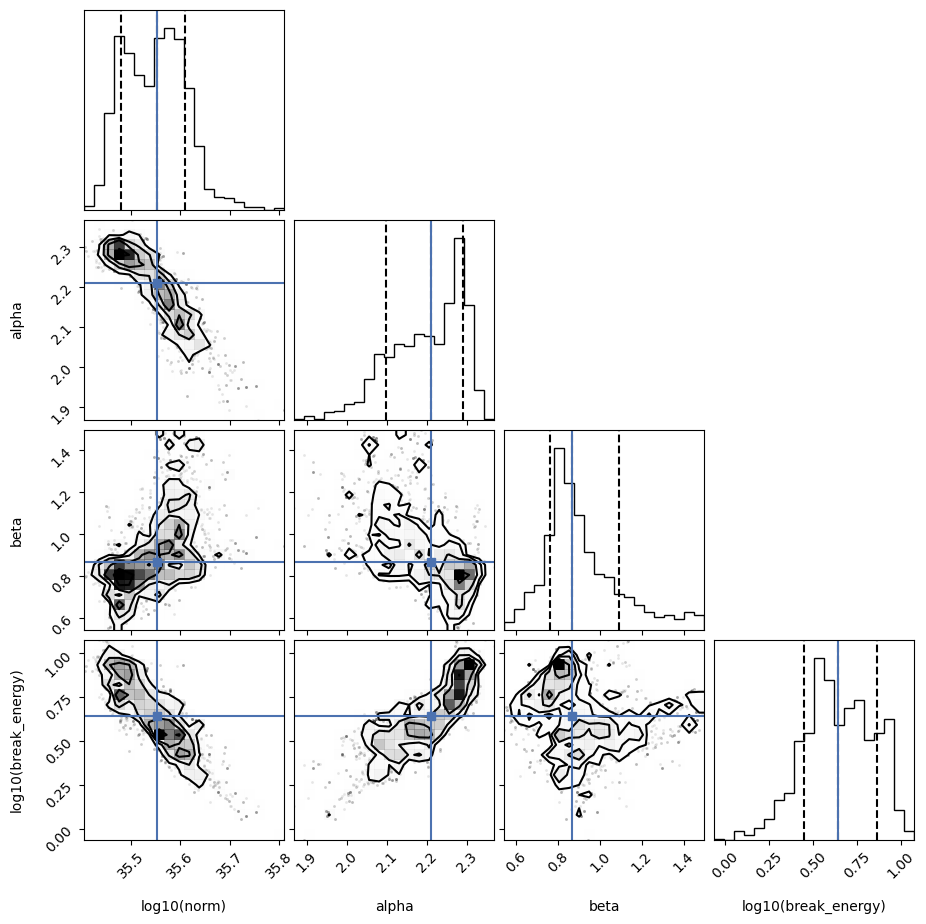

In [14]:
from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)
#plt.savefig("corner_hadronic.png")

In [15]:
get_BIC(sampler)

BIC value for model: 135.504


Proton log10(norm): 35.55257523432675 (-0.07297019769503521 + 0.05674180982624932)
Proton spectral index alpha: 2.2105293978034632 (-0.11391433804213191 + 0.07840653852090895)
Proton spectral index beta: 0.8655275948080341 (-0.1025112567093921 + 0.22757028734926665)
Proton log10(break_energy): 0.640665199126141 (-0.19062297270129508 + 0.22619095777814446)

[Gamma-ray spectrum (Hadronic)]
dN/dE (1 TeV): 4.103e-12 1 / (TeV s cm2) (-1.044e-12 1 / (TeV s cm2), +9.656e-13 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 4.103e-12 TeV / (s cm2) (-1.044e-12 TeV / (s cm2), +9.656e-13 TeV / (s cm2))
Gamma-ray index @1 TeV: 2.631 (--0.090, +-0.101)
Estimated gamma-ray break from modeled spectrum: 0.571 TeV (-0.222 TeV, +0.417 TeV)
Local gamma-ray indices: low=2.096, high=2.857
Total proton energy Wp (>1 GeV): 1.010e+49 erg (-4.393e+48 erg, +5.633e+48 erg)


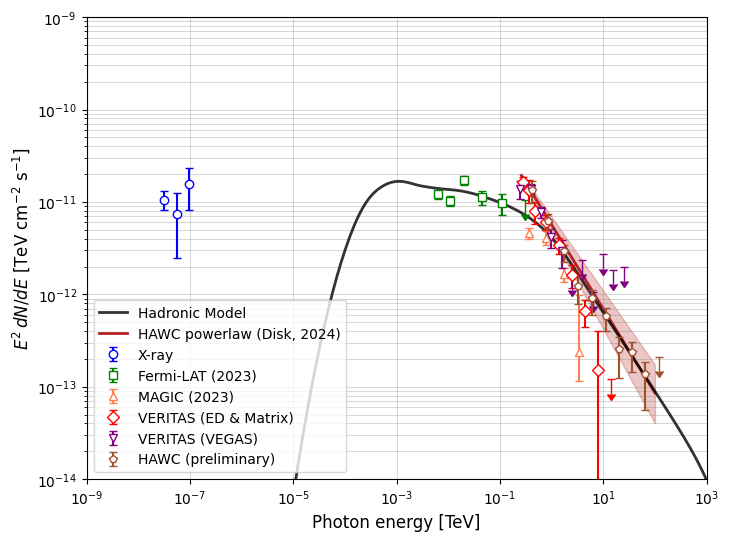

In [20]:
print(f"Proton log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Proton spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
print(f"Proton spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
print(f"Proton log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

fig,ax = plt.subplots(figsize=(8,6))
plot_hadronic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, gas_density=gas_density, distance=distance, ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

ax.set_xlim(left=1e-9)
ax.legend(loc='lower left')
#plt.show()
plt.savefig('hadronic_hawc_xray_bpl.png')

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [39.47675835  2.          1.30103   ] [naima.core]
INFO:    Initial lnprob(p0): -6834295324.983 [naima.core]
INFO:    New ML parameters : [35.94334413  2.20992761  1.31375426] [naima.core]
INFO:    Maximum lnprob(p0): -64.144 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.9            2.21            1.31      
  Last ensemble std    :      0.151          0.0104          0.00715    
  Last ensemble lnprob :  avg: -104.026, max: -63.959

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.9            2.21            1.31      
  Last ensemble std    :      0.145          0.0113          0.00786    

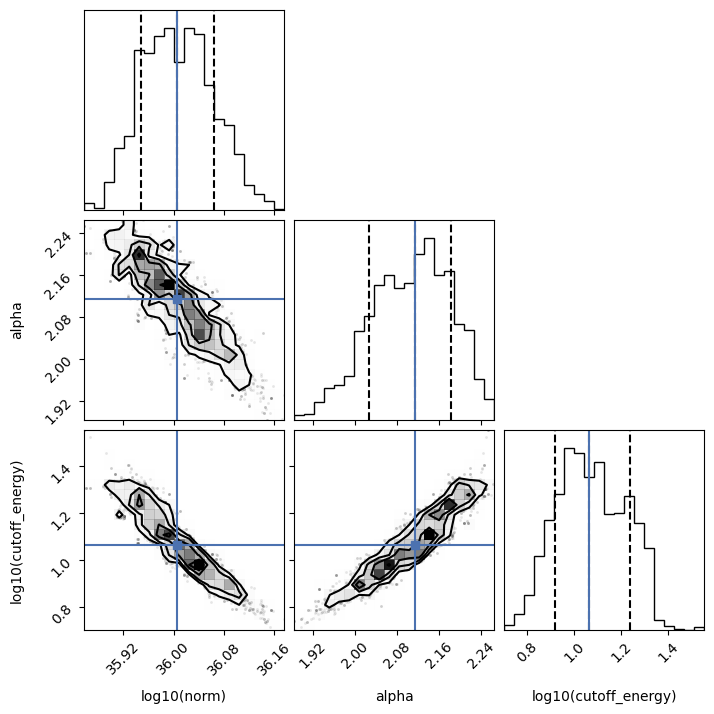

In [22]:
model_type = "ECPL"    # Broken vs. exponential cutoff power-law (ECPL)
gas_density = 20 * u.cm**-3
distance = 2 * u.kpc
p0 = default_params_HadronicModel[model_type]["p0"]
labels = default_params_HadronicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(data_table=datatable, 
                                 p0=p0,
                                 labels=labels,
                                 model=HadronicModel_wrapper,
                                 prior=lnprior_wrapper,
                                 nwalkers=32,
                                 nburn=20,
                                 nrun=100,
                                 threads=4,
                                 prefit=True,
                                 data_sed=True)

MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Hadronic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

get_BIC(sampler)

In [17]:
print(f"Proton log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Proton spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
print(f"Proton log10(cutoff_energy): {MLp_dict['log10(cutoff_energy)']['median']} (-{MLp_dict['log10(cutoff_energy)']['err_low']} + {MLp_dict['log10(cutoff_energy)']['err_high']})")

fig,ax = plt.subplots(figsize=(8,6))
plot_hadronic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, gas_density=gas_density, distance=distance, ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

ax.set_xlim(left=1e-9)
ax.legend()
#plt.show()
plt.savefig('hadronic_ecpl.png')

Proton log10(norm): 35.55257523432675 (-0.07297019769503521 + 0.05674180982624932)
Proton spectral index alpha: 2.2105293978034632 (-0.11391433804213191 + 0.07840653852090895)


KeyError: 'log10(cutoff_energy)'

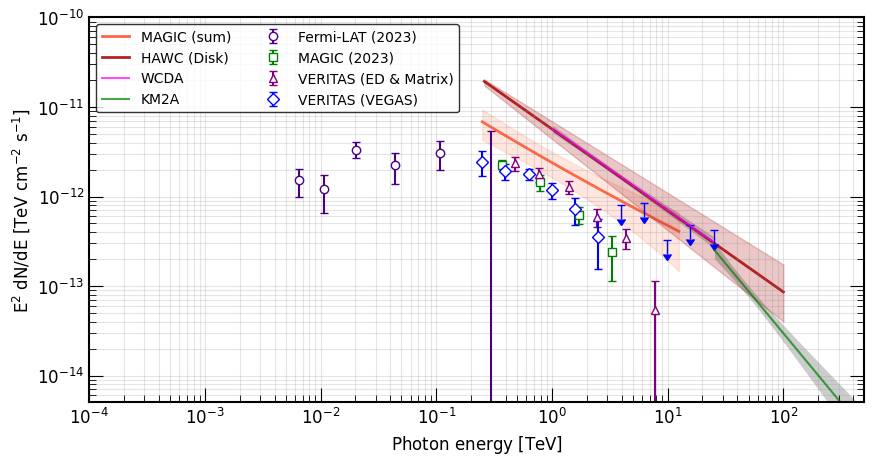

In [46]:
import matplotlib as mpl
x_unit  = u.TeV
y_unit = u.Unit('TeV cm-2 s-1')

mpl.rcParams['axes.linewidth'] = 1.5 
fig,ax = plt.subplots(figsize=(10,5))
color = ['indigo', 'green', 'purple', 'blue', 'coral']
marker = ['o','s', '^', 'D', 'v' ]



i = 0
for keys in fit_dic.keys():
    plot_data_script(ax, fit_dic[keys], color= color[i], marker=marker[i], energy_unit='TeV', flux_unit='TeV cm-2 s-1', label=keys)
    i +=1
    
#plot_data_script(ax, fermi_data, 'darkorange', 'o', 'TeV', 'erg cm-2 s-1')

#wcda_pl.plot(energy_bounds=[1, 25]*u.TeV, ax=ax,alpha=0.7, energy_power=2, color='red')
#wcda_pl.plot_error(energy_bounds=[1, 25]* u.TeV,  ax=ax, energy_power=2, color='red', alpha=0.5,label='WCDA')

#km2a_pl.plot(energy_bounds=[1, 25]*u.TeV, ax=ax,alpha=0.7, energy_power=2, color='red')
#km2a_pl.plot_error(energy_bounds=[25, 100]* u.TeV,  ax=ax, energy_power=2, color='red', alpha=0.5,label='km2a')

#if np.any(det):
    #ax.errorbar(x=E_mine[det], y=E_mine[det]**2*F_mine[det], yerr=E_mine[det]**2*dF_mine[det], fmt='o', ms=4, lw=1, color='grey', label="VERITAS (VEGAS old)", zorder=2)

# plot upper limits as downward arrows (errorbar with yerr positive-only)
#if np.any(ul):
    #ax.errorbar(x=E_mine[ul], y=E_mine[ul]**2*F_mine[ul], yerr=E_mine[ul]**2*0.2*F_mine[ul], uplims=True, color='grey', ls='',
               #capsize=3, marker='.', elinewidth=1, zorder=2, markersize=0, xerr=None)


# Parameters from MAGIC 2023 (Table 3, p. 9).
# Units: N0 in TeV^-1 cm^-2 s^-1, E0 in TeV, E in TeV
MAGIC = {
    "SNR Shell": {
        "N0": 10e-13, "dN0_stat": 2e-13, "dN0_sys_lo": 3.5e-13, "dN0_sys_hi": 6.7e-13,
        "Gamma": 2.55, "dG_stat": 0.16, "dG_sys_lo": 0.25, "dG_sys_hi": 0.30,
        "E0": 1.0, "color": "tab:green"
    },
    "MAGIC J2019+408": {
        "N0": 10.0e-13, "dN0_stat": 0.9e-13, "dN0_sys_lo": 3.5e-13, "dN0_sys_hi": 6.0e-13,
        "Gamma": 2.81, "dG_stat": 0.10, "dG_sys_lo": 0.19, "dG_sys_hi": 0.21,
        "E0": 1.0, "color": "tab:blue"
    },
    # Choose ONE arc template to plot; here we use the annular sector (you can switch to Gaussian if preferred)
    "Arc (annular)": {
        "N0": 3.9e-13, "dN0_stat": 0.7e-13, "dN0_sys_lo": 1.5e-13, "dN0_sys_hi": 2.6e-13,
        "Gamma": 3.02, "dG_stat": 0.18, "dG_sys_lo": 0.20, "dG_sys_hi": 0.22,
        "E0": 1.0, "color": "tab:orange"
    },
}

INCLUDE_SYSTEMATICS = True

def total_err(stat, lo, hi):
    """Combine stat and asymmetric sys in quadrature; use average sys = 0.5*(lo+hi)."""
    if INCLUDE_SYSTEMATICS:
        sys_avg = 0.5 * (lo + hi)
        return np.sqrt(stat**2 + sys_avg**2)
    else:
        return stat

# Build symmetric 1σ for each component
for name, p in MAGIC.items():
    p["dN0"] = total_err(p["dN0_stat"], p["dN0_sys_lo"], p["dN0_sys_hi"])
    p["dG"]  = total_err(p["dG_stat"],  p["dG_sys_lo"],  p["dG_sys_hi"])

# --------- Energy grid (MAGIC range) ---------
E = np.logspace(np.log10(0.25), np.log10(12.5), 500)  # TeV

# Plot individual components + 1σ bands
y_components = []
sig_components = []
labels_plotted = []

for name, p in MAGIC.items():
    y  = e2_dnde(E, p["N0"], p["E0"], p["Gamma"])
    sy = e2_dnde_sigma(E, p["N0"], p["dN0"], p["E0"], p["Gamma"], p["dG"])
    #ax.plot(E, y, color=p["color"], lw=2, label=f"{name}: Γ={p['Gamma']:.2f}")
    #ax.fill_between(E, y - sy, y + sy, color=p["color"], alpha=0.25)
    y_components.append(y)
    sig_components.append(sy)
    labels_plotted.append(name)

# --------- Sum of MAGIC components (optional) ---------
y_sum  = np.sum(y_components, axis=0)
# assume components' errors uncorrelated -> variances add
sy_sum = np.sqrt(np.sum([s**2 for s in sig_components], axis=0))

ax.plot(E, y_sum, color="tomato", lw=2, ls="-", label="MAGIC (sum)", zorder=1)
ax.fill_between(E, y_sum - sy_sum, y_sum + sy_sum, color="coral", alpha=0.18, zorder=1)



### Fermi & HAWC (2019) ###
'''
    "LAT Disk":     dict(E0=1e-3, K=1.50e-5, dK=0.06e-5, Gamma=2.06, dGamma=0.02,
                         color="dodgerblue", ls="-", E_range=(1e-3, 0.87)),
    "LAT Hotspot":  dict(E0=1e-3, K=2.80e-6, dK=0.6e-6, Gamma=2.11, dGamma=0.09,
                         color="olive", ls=":", E_range=(1e-3, 0.87)),
'''
params = {
    "HAWC (Disk)": dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                        color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1)
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

wcda_pl.plot(energy_bounds=[1, 25]*u.TeV, ax=ax,alpha=0.7, energy_power=2, color='magenta',label='WCDA')
wcda_pl.plot_error(energy_bounds=[1, 25]* u.TeV,  ax=ax, energy_power=2, color='red', alpha=0.2)

km2a_pl.plot(energy_bounds=[25, 500]*u.TeV, ax=ax,alpha=0.7, energy_power=2, color='green',label='KM2A')
km2a_pl.plot_error(energy_bounds=[25, 500]* u.TeV,  ax=ax, energy_power=2, color='green', alpha=0.2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-4, 5e2)
ax.set_ylim(5e-15,1e-10)
ax.grid(which='both', color='gray', alpha=0.2)

leg = ax.legend(ncol=2)
ax.tick_params(which='minor', length=5) 
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor('white')
ax.tick_params(axis='both', which='both', labelsize=12, right=True, direction='in')
ax.tick_params(which='major', length=10)
ax.set_xlabel('Photon energy [{0}]'.format(x_unit.to_string('latex_inline')), size=12)
ax.set_ylabel('$\mathrm{E^{2} \ dN/dE  \ [\mathrm{TeV \ cm^{-2} \ s^{-1}}]}$', size=12)  
#plt.show()
plt.savefig('gCygni_hotspot-BroadBand.png', dpi=300, bbox_inches='tight')

In [18]:
from main.models import LeptonicModel, lnprior_LeptonicModel, default_params_LeptonicModel
model_type = "BPL"
gas_density = 2.5 * u.cm**-3
distance = 2 * u.kpc



def LeptonicModel_wrapper(pars, data):
    return LeptonicModel(pars, data, model_type=model_type, distance=distance)[0]
    # [0] because LeptonicModel returns (model_flux, (eE, eDist), We)

def lnprior_wrapper(pars):
    return lnprior_LeptonicModel(pars, model_type=model_type)

p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    data_sed=True,
    prefit=True,
)


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [nan 2.  1.  0.6] [naima.core]
INFO:    Initial lnprob(p0): -inf [naima.core]


Burning in the 32 walkers with 20 steps...


ValueError: Initial state has a large condition number. Make sure that your walkers are linearly independent for the best performance

In [13]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(35.74892584773284), 'err_low': np.float64(0.03528262029173135), 'err_high': np.float64(0.023625547576997974)}, 'alpha': {'median': np.float64(2.8520069791208833), 'err_low': np.float64(0.07813402509232725), 'err_high': np.float64(0.05672140419635241)}, 'log10(cutoff_energy)': {'median': np.float64(0.9300123220149877), 'err_low': np.float64(0.043049625282782444), 'err_high': np.float64(0.041490698858626995)}}


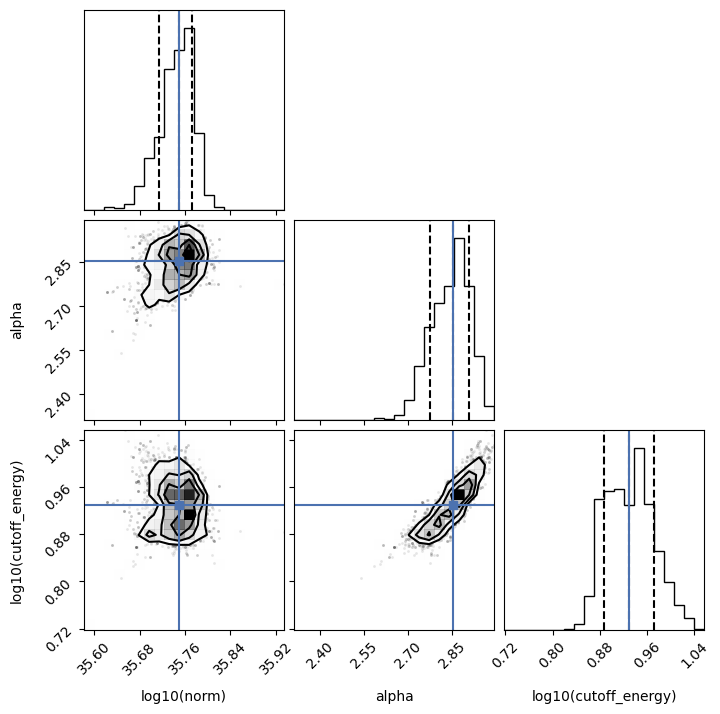

In [14]:
from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)
plt.savefig("corner_leptonic.png")

In [15]:
get_BIC(sampler)

BIC value for model: 120.831


In [16]:
#naima.plot_fit(sampler, sed=True, n_samples=100, plotdata=True, plotresiduals=None, e_unit=u.TeV, xlabel=None, ylabel=None, ulim_opts={}, errorbar_opts={})

Electron log10(norm): 35.74892584773284 (-0.03528262029173135 + 0.023625547576997974)
Electron spectral index alpha: 2.8520069791208833 (-0.07813402509232725 + 0.05672140419635241)

[Gamma-ray spectrum (Leptonic IC)]
dN/dE (1 TeV): 3.683e-12 1 / (TeV s cm2) (-1.447e-13 1 / (TeV s cm2), +1.806e-13 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 3.683e-12 TeV / (s cm2) (-1.447e-13 TeV / (s cm2), +1.806e-13 TeV / (s cm2))
Gamma-ray index @1 TeV: 2.813 (--0.033, +-0.035)
Estimated gamma-ray break from modeled IC spectrum: 14.803 TeV (-0.000 TeV, +-0.404 TeV)
Local gamma-ray indices from IC model: low=1.944, high=8.986
Total electron energy We (>1 GeV): 3.788e+50 erg (-1.550e+50 erg, +1.765e+50 erg)


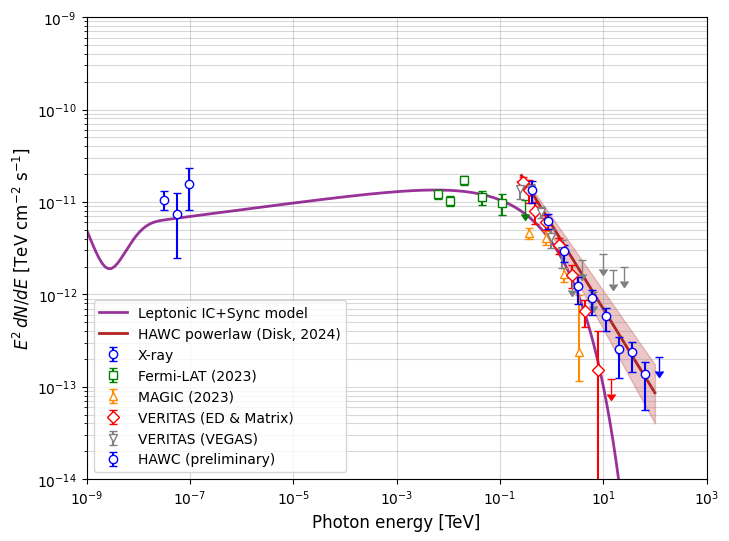

In [17]:
print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
#print(f"Electron spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
#print(f"Electron log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
                    energy_range=(1e-9, 1e3), label="Leptonic IC+Sync model", color="purple", ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

ax.set_xlim(left=1e-9)
ax.legend()

plt.show()
#plt.savefig('leptonic_bpl.png')

In [20]:
model_type = "ECPL"
gas_density = 20 * u.cm**-3
distance = 2 * u.kpc


p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    prefit=True,
)



INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [38.55758809  2.          1.        ] [naima.core]
INFO:    Initial lnprob(p0): -11179780884.867 [naima.core]
INFO:    New ML parameters : [35.68889158  2.63621587  0.84249975] [naima.core]
INFO:    Maximum lnprob(p0): -53.202 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.7            2.63            0.843     
  Last ensemble std    :      0.153           0.014          0.00386    
  Last ensemble lnprob :  avg: -114.224, max: -53.263

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.7            2.64            0.843     
  Last ensemble std    :      0.143          0.0143          0.00557   

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(35.69755691927981), 'err_low': np.float64(0.03632638429980517), 'err_high': np.float64(0.036812673011162644)}, 'alpha': {'median': np.float64(2.672087235800819), 'err_low': np.float64(0.10217454878236332), 'err_high': np.float64(0.11281589954320204)}, 'log10(cutoff_energy)': {'median': np.float64(0.8596928979837442), 'err_low': np.float64(0.05386415881821072), 'err_high': np.float64(0.0533910070874678)}}
BIC value for model: 116.885
Electron log10(norm): 35.69755691927981 (-0.03632638429980517 + 0.036812673011162644)
Electron spectral index alpha: 2.672087235800819 (-0.10217454878236332 + 0.11281589954320204)
Electron log10(cutoff_energy): 0.8596928979837442 (-0.05386415881821072 + 0.0533910070874678)

[Gamma-ray spectrum (Leptonic IC)]
dN/dE (1 TeV): 3.950e-12 1 / (TeV s cm2) (-2.139e-13 1 / (TeV s cm2), +1.640e-14 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 3.950e-12 TeV / (s cm2) (-2.139e-13 TeV / (s cm2), +1.640e

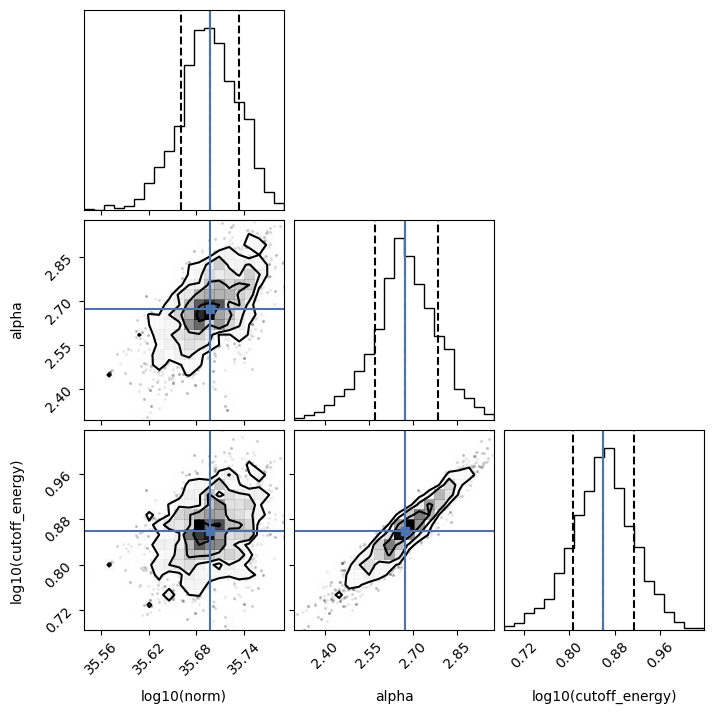

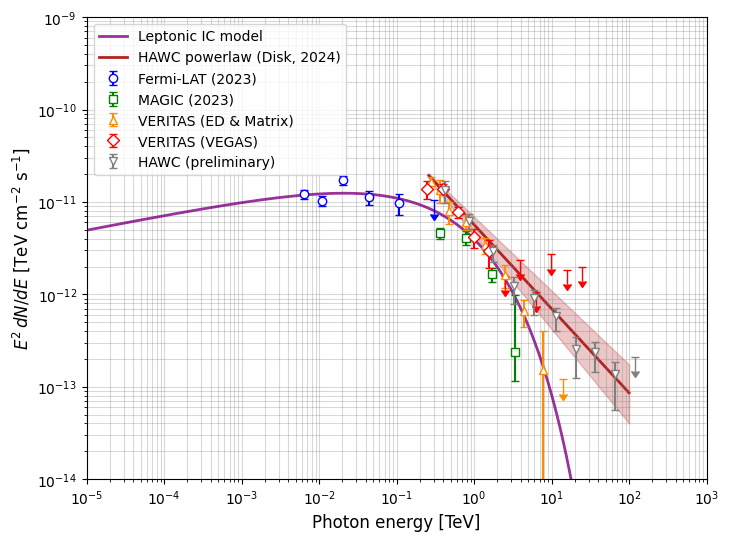

In [22]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

get_BIC(sampler)

print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
print(f"Electron log10(cutoff_energy): {MLp_dict['log10(cutoff_energy)']['median']} (-{MLp_dict['log10(cutoff_energy)']['err_low']} + {MLp_dict['log10(cutoff_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
    label="Leptonic IC model",
    color="purple", ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

ax.legend()

#plt.show()
plt.savefig('leptonic_ecpl.png')

In [4]:
import numpy as np

# Parameters
phi_0 = 1e-12  # normalization in TeV^-1 cm^-2 s^-1
E0 = 1.0       # pivot energy in TeV
alpha = -2.9   # spectral index
Emin = 1.0     # lower bound of integration in TeV
Emax = 100.0   # upper bound of integration in TeV
sigma_deg = 2  # Gaussian sigma in degrees

# Convert sigma to radians
sigma_rad = np.deg2rad(sigma_deg)

# Solid angle for 2D Gaussian source (in steradians)
omega = 2 * np.pi * sigma_rad**2  # sr

# Integral flux per cm^2 s
def integral_flux(phi_0, E0, alpha, Emin, Emax):
    if alpha == -1:
        return phi_0 * np.log(Emax / Emin)
    else:
        prefactor = phi_0 * E0**(-alpha)
        integral = (Emax**(alpha + 1) - Emin**(alpha + 1)) / (alpha + 1)
        return prefactor * integral

# Compute integral flux (cm^-2 s^-1)
flux_per_cm2 = integral_flux(phi_0, E0, alpha, Emin, Emax)

# Total photon flux from whole source (photons/s)
total_flux = flux_per_cm2 * omega

# Print results
print(f"Integral flux per cm^2/s: {flux_per_cm2:.2e} cm^-2 s^-1")
print(f"Solid angle of source: {omega:.2e} sr")
print(f"Total photon flux from source: {total_flux:.2e} photons/s")


Integral flux per cm^2/s: 5.26e-13 cm^-2 s^-1
Solid angle of source: 7.66e-03 sr
Total photon flux from source: 4.03e-15 photons/s


In [78]:
BINS_nn="B2C0Ea B2C0Eb B2C0Ec B2C0Ed B2C0Ee B2C0Ef B3C0Eb B3C0Ec B3C0Ed B3C0Ee B3C0Ef B4C0Eb B4C0Ec B4C0Ed B4C0Ee B4C0Ef B4C0Eg B5C0Ec B5C0Ed B5C0Ee B5C0Ef B5C0Eg B5C0Eh B6C0Ed B6C\
0Ee B6C0Ef B6C0Eg B6C0Eh B6C0Ei B7C0Ee B7C0Ef B7C0Eg B7C0Eh B7C0Ei B8C0Eg B8C0Eh B8C0Ei B8C0Ej B9C0Eg B9C0Eh B9C0Ei B9C0Ej B9C0Ek B10C0Eg B10C0Eh B10C0Ei B10C0Ej B10C0Ek B10C0El"

In [79]:
BINS_gp = "B2C0Ea B2C0Eb B2C0Ec B2C0Ed B2C0Ee B2C0Ef B2C0Eg B3C0Eb B3C0Ec B3C0Ed B3C0Ee B3C0Ef B3C0Eg B4C0Ec B4C0Ed B4C0Ee B4C0Ef B4C0Eg B5C0Ec B5C0Ed B5C0Ee B5C0Ef B5C0Eg B5C0Eh B6C\
0Ed B6C0Ee B6C0Ef B6C0Eg B6C0Eh B7C0Ee B7C0Ef B7C0Eg B7C0Eh B7C0Ei B8C0Ef B8C0Eg B8C0Eh B8C0Ei B8C0Ej B9C0Eg B9C0Eh B9C0Ei B9C0Ej B9C0Ek B10C0Eg B10C0Eh B10C0Ei B10C0Ej B10C0Ek B10C\
0El"

In [80]:
BINS_gp = BINS_gp.split(" ")
BINS_nn = BINS_nn.split(" ")

In [81]:
set_gp = set(BINS_gp)
set_nn = set(BINS_nn)

In [82]:
# Find differences
only_in_nn = set_nn - set_gp
only_in_gp = set_gp - set_nn

In [83]:
only_in_nn

{'B4C0Eb', 'B6C0Ei'}

In [84]:
only_in_gp

{'B2C0Eg', 'B3C0Eg', 'B8C0Ef'}

In [87]:
len(BINS_gp), len(BINS_nn)

(50, 49)

In [95]:
import numpy as np

# Inputs
E0 = 1.0  # TeV
norm = 1e-12  # normalization at E0
gamma = 2.9   # spectral index

# Example covariance matrix (2x2): [ [var_norm, cov], [cov, var_index] ]
# Assume you already have this from your fit
cov_matrix = np.array([
    [1e-26, -2e-14],   # cov(N0, N0), cov(N0, gamma)
    [-2e-14, 0.04]     # cov(gamma, N0), var(gamma)
])

cov_N_gamma = cov_matrix[0, 1]
var_gamma = cov_matrix[1, 1]
norm2 = (0.2e-12)**2

# Compute pivot energy
pivot_energy = E0 * np.exp(cov_N_gamma / (norm2 * var_gamma))
print(f"Pivot energy: {pivot_energy:.3f} TeV")


Pivot energy: 0.000 TeV


In [94]:
var_gamma

0.04